# Greath North Run data processing

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw_df = pd.read_excel("2024 Data Challenge Raw Data.xlsx")
raw_df.shape

(14614, 17)

## Row descriptions
|Variable |	Definition |
| :-: | :- |
| club |	The club the runner is a part of 
|position |	The position the runner finished in 
|time |	The time the runner took to finish the race
|id |	The runners id
|gender	| The runners gender
|trained_10_week |	The average number of times per week the runner trained 10 or more weeks ago
|trained_im	| The average number of times per week the runner trained less than e weeks ago
|has_trainer |	Whether the runner has a trainer or not
|cadence |	The average number of steps the runner took per minute
|age |	The age of the runner
|bmi |	The bmi of the runner
|n_marathons_run |	The number of marathons the runner has run before the race
|bib_colour |	The runners bib colour
|VO2_max |	The VO2 max of the runner
|heart_rate	| The resting heart rate of the runner
|shoe_size	| The runner's shoe size


NOTE:  
*Bib colours have meaning:  
Orange: 

In [3]:
raw_df.head()

#figure out unnamed column name- external sources?
#fix club names for all the records, fill up until you find text

,Unnamed: 0,club,position,time,id,gender,trained_10_week,trained_im,has_trainer,cadence,age,bmi,n_marathons_run,bib_colour,VO2_max,heart_rate,shoe_size
0,7448,NaN,14589,03:45:46,7426,female,0.789725,0.789725,0,163,36.0,999.00,0.0,green,12.718323,103.67,6
1,5363,NaN,14588,03:26:28,5345,female,1.670838,1.670838,0,157,30.0,19.05,0.0,green,12.718323,99.33,5
2,11420,NaN,14587,03:26:22,11387,female,1.917839,1.917839,0,165,38.0,21.13,0.0,green,13.460000,98.43,6
3,9408,Gump's training,14586,03:21:13,9384,male,0.000000,0.000000,0,154,38.0,18.86,0.0,green,20.010000,100.91,7
4,6604,NaN,14585,03:20:19,6585,female,0.000000,0.710092,0,166,43.0,19.75,0.0,green,12.718323,102.45,6


In [4]:
#no of missing values in each column 
raw_df.isnull().sum()

Unnamed: 0             0
club               11425
position               0
time                  47
id                     0
gender                 0
trained_10_week       74
trained_im           151
has_trainer            0
cadence                0
age                   51
bmi                    0
n_marathons_run       37
bib_colour             0
VO2_max              572
heart_rate           550
shoe_size              0
dtype: int64

In [5]:
raw_df.describe()

,Unnamed: 0,position,id,trained_10_week,trained_im,has_trainer,cadence,age,bmi,n_marathons_run,VO2_max,heart_rate,shoe_size
count,14614.000000,14614.000000,14614.000000,14540.000000,14463.000000,14614.000000,14614.000000,14563.000000,14614.000000,14577.000000,14042.000000,14064.000000,14614.000000
mean,7328.758656,7280.848159,7306.500000,-3.083608,-8.237465,0.078692,159.093540,36.102383,60.647316,3084.041984,44.585019,81.290607,7.656631
std,4231.313944,4219.205169,4218.842752,75.482450,106.119666,0.269266,32.010322,9.891467,189.231907,54865.742122,19.961066,10.775136,3.041907
min,0.000000,1.000000,0.000000,-999.000000,-999.000000,0.000000,1.000000,18.000000,15.050000,-9.000000,10.010000,58.680000,3.000000
25%,3665.250000,3627.250000,3653.250000,1.183613,2.008240,0.000000,161.000000,30.000000,21.120000,3.000000,28.260000,72.207500,5.000000
50%,7328.500000,7280.500000,7306.500000,2.745488,3.251724,0.000000,165.000000,36.000000,22.610000,6.000000,43.280000,80.740000,7.000000
75%,10992.750000,10933.750000,10959.750000,4.023773,4.332161,0.000000,169.000000,42.000000,24.180000,11.000000,60.827500,89.952500,10.000000
max,14660.000000,14589.000000,14613.000000,6.919653,6.919653,1.000000,189.000000,83.000000,999.000000,1000000.000000,95.850000,114.830000,13.000000


In [6]:

print(raw_df.bib_colour.value_counts())

bib_colour
green     5785
blue      4397
yellow    2925
red       1507
Name: count, dtype: int64


In [7]:
raw_df.columns
raw_df.dropna(subset=['time'], inplace=True)
raw_df['time_seconds'] = pd.to_timedelta(raw_df['time']).dt.total_seconds().astype(int)

# Make a copy so we don't accidentally alter the original
data = raw_df.copy()

# Remove the automatically-created index column if it isn't useful
data = data.drop(columns=["Unnamed: 0"], errors="ignore")
data["time_hours"] = data["time_seconds"] / 3600


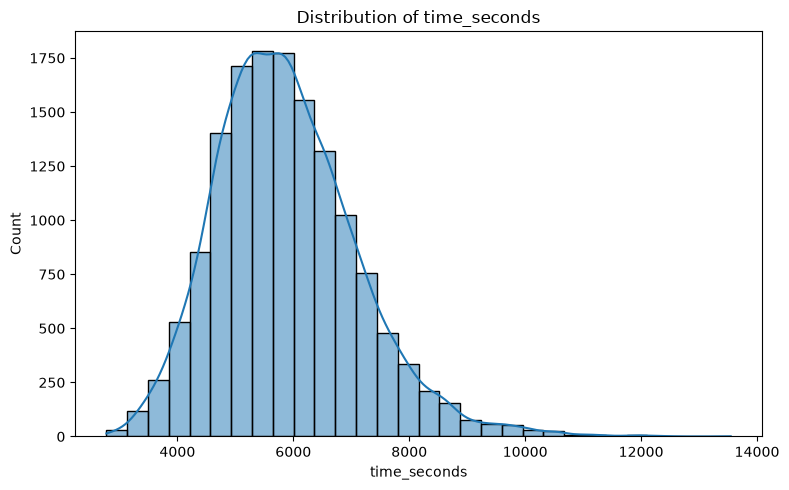

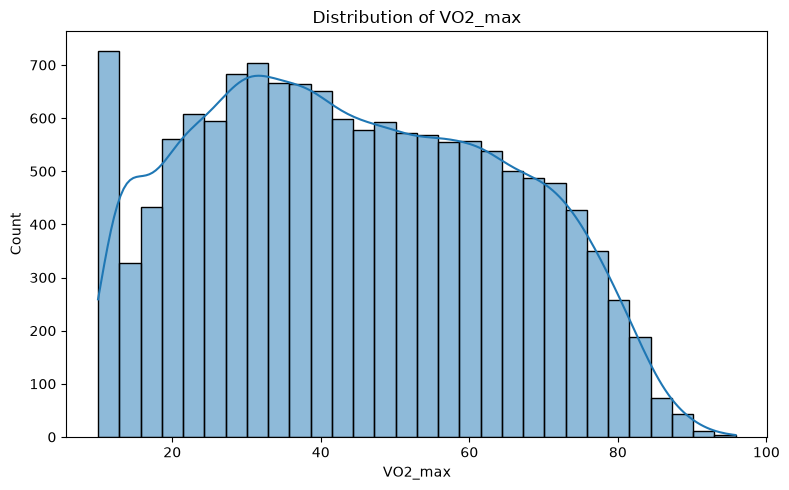

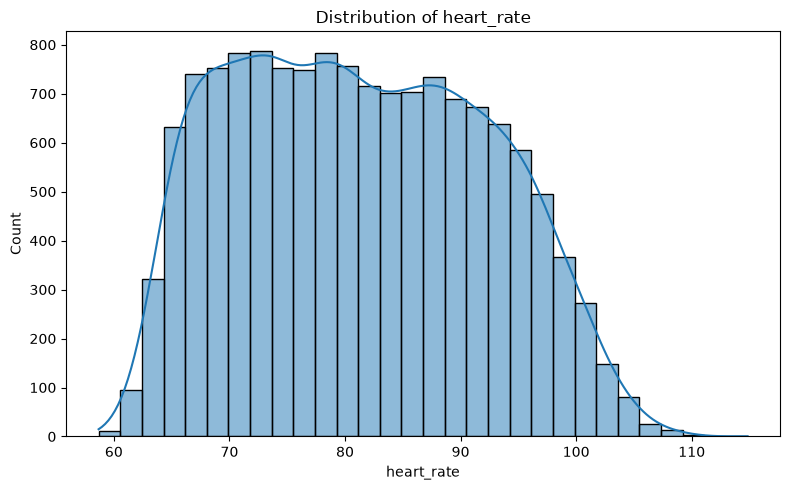

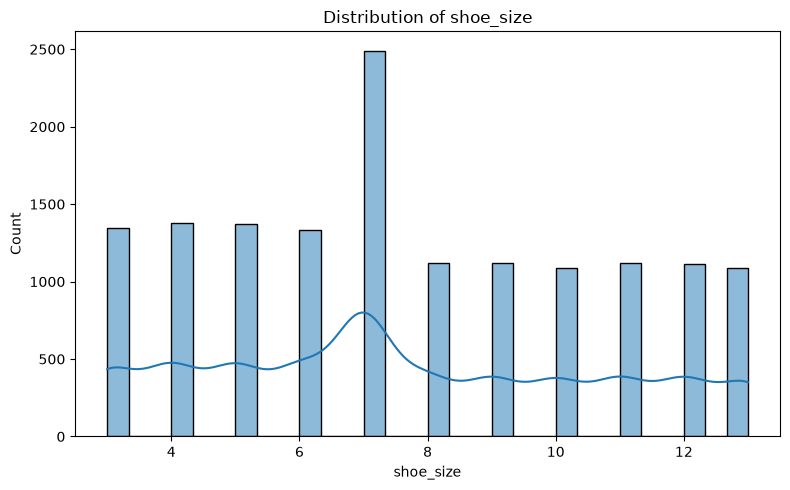

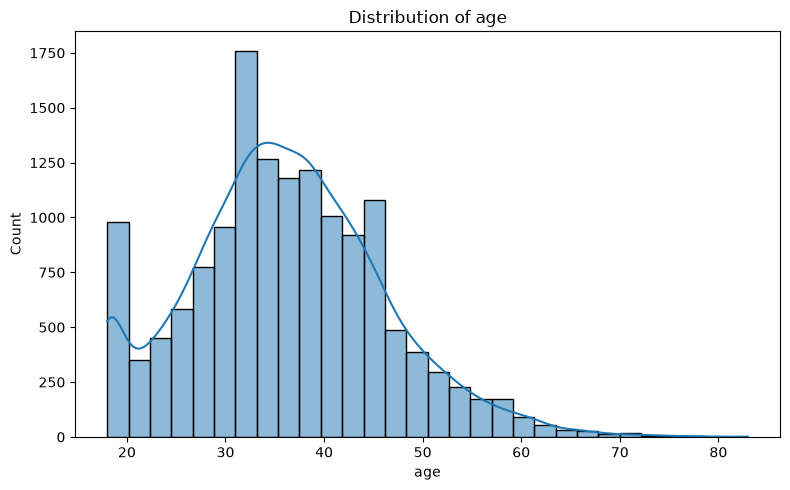

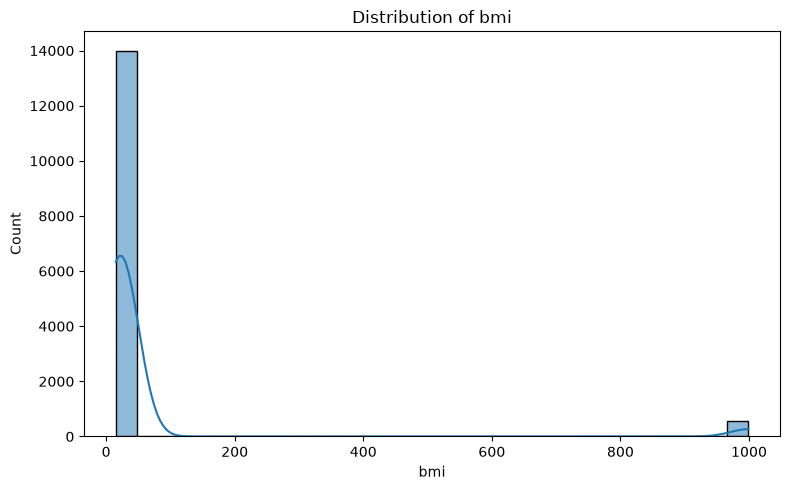

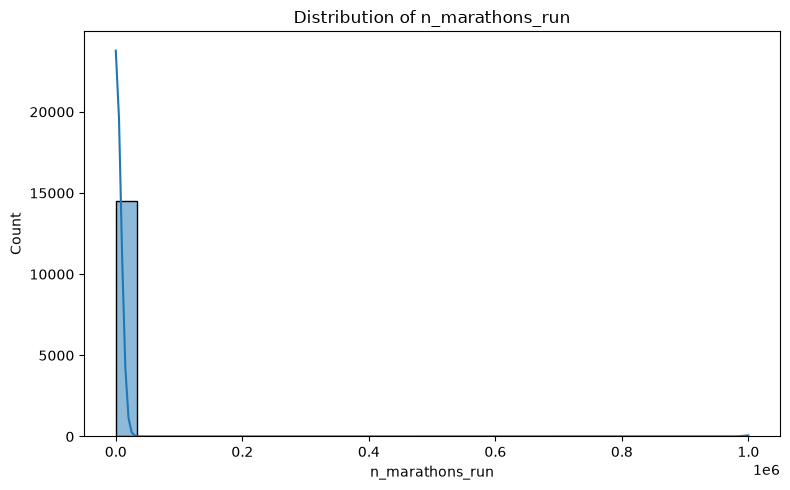

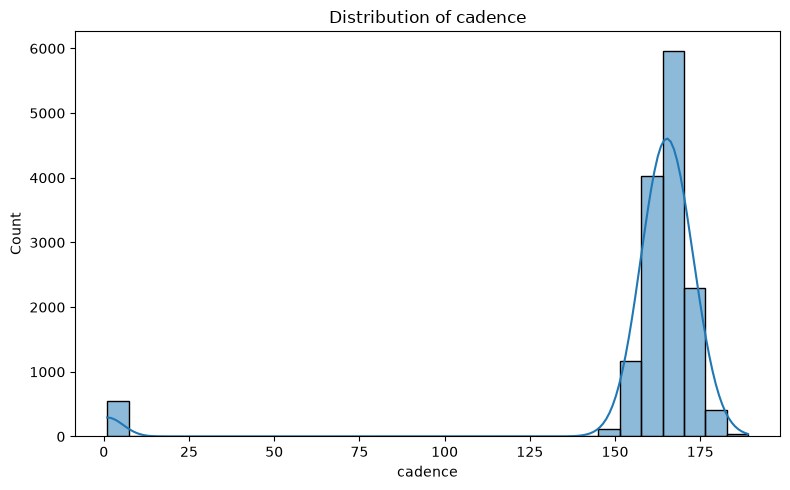

In [8]:
# distribution plots for all numerical
numeric_cols = [
    "time_seconds",
    "VO2_max",
    "heart_rate",
    "shoe_size",
    "age",
    "bmi",
    "n_marathons_run",
    "cadence"
]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=data,
        x=col,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()


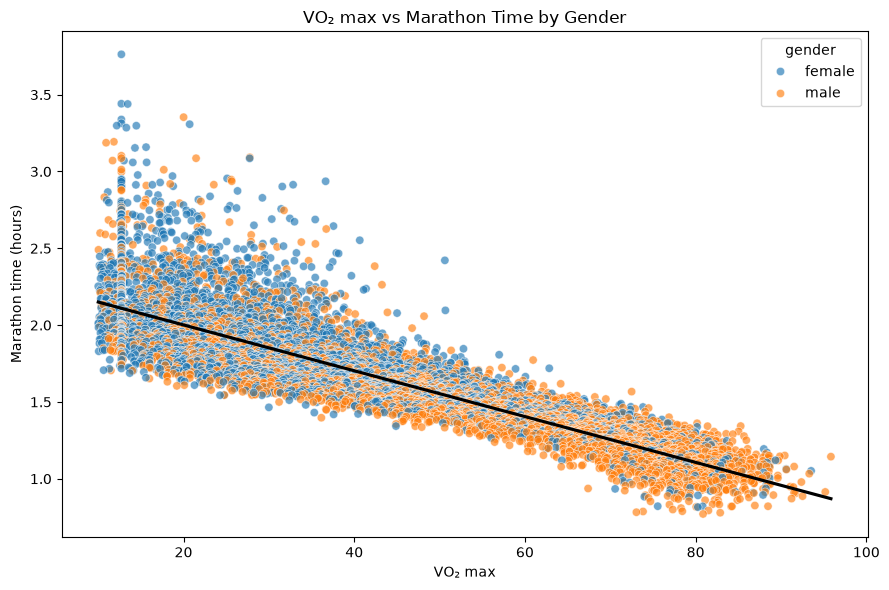

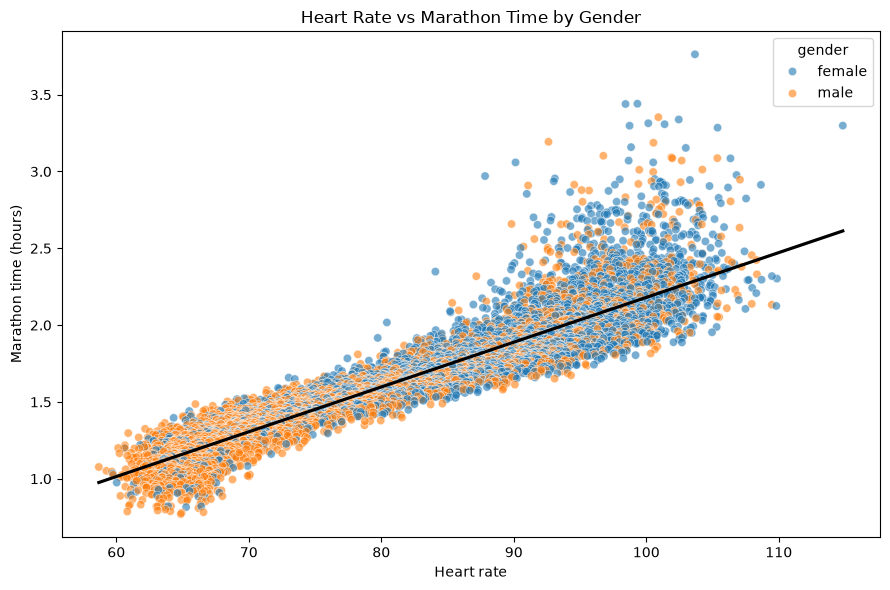

In [9]:
# vo2 and heart rate by gender by time
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="VO2_max",
    y="time_hours",
    hue="gender",
    alpha=0.65
)

sns.regplot(
    data=data,
    x="VO2_max",
    y="time_hours",
    scatter=False,
    color="black"
)

plt.xlabel("VO₂ max")
plt.ylabel("Marathon time (hours)")
plt.title("VO₂ max vs Marathon Time by Gender")

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="heart_rate",
    y="time_hours",
    hue="gender",
    alpha=0.6
)

sns.regplot(
    data=data,
    x="heart_rate",
    y="time_hours",
    scatter=False,
    color="black"
)

plt.xlabel("Heart rate")
plt.ylabel("Marathon time (hours)")
plt.title("Heart Rate vs Marathon Time by Gender")

plt.tight_layout()
plt.show()


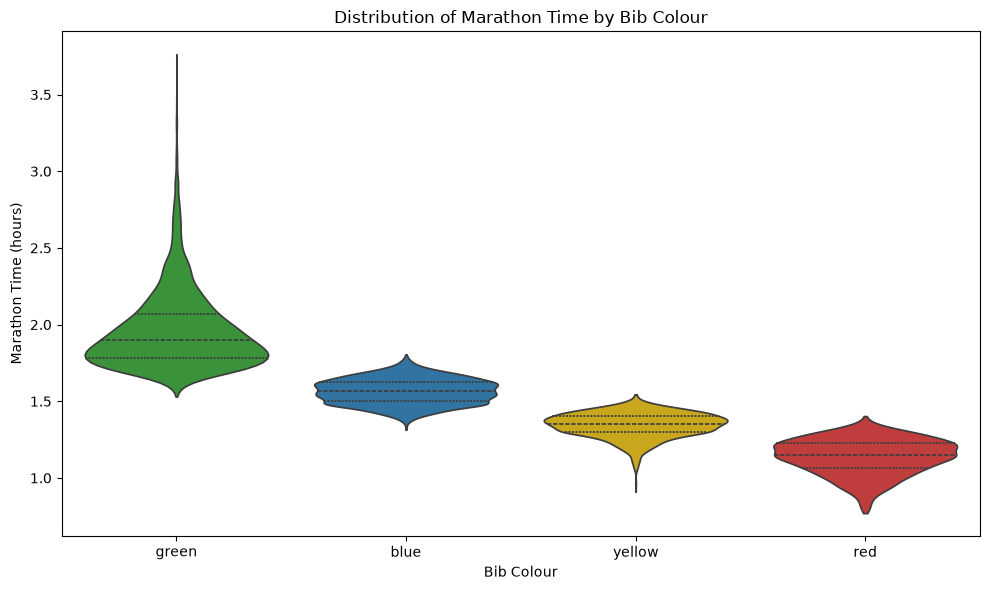

In [10]:
# bib colour clusters

# Define colours for each bib colour
bib_colors = {
    "red": "#D62728",
    "blue": "#1F77B4",
    "green": "#2CA02C",
    "yellow": "#E6B800",   # golden yellow
}

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=data,
    x="bib_colour",
    y="time_hours",
    hue="bib_colour",
    palette=bib_colors,
    inner="quartile",
    cut=0,
    legend=False
)

plt.xlabel("Bib Colour")
plt.ylabel("Marathon Time (hours)")
plt.title("Distribution of Marathon Time by Bib Colour")

plt.tight_layout()
plt.show()


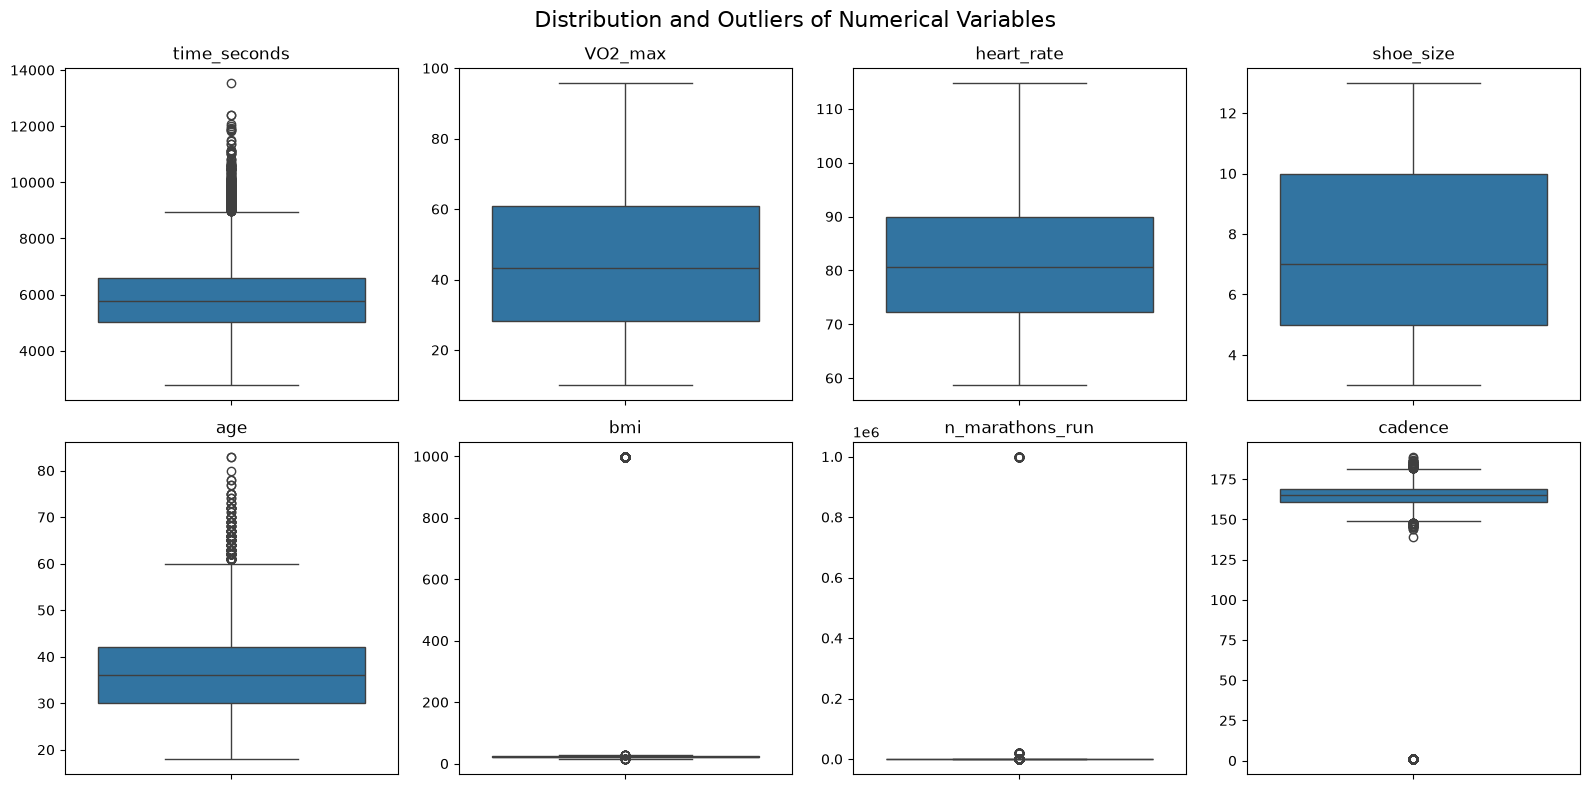

In [11]:
# showing outliers

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(
        data=data,
        y=col,
        ax=ax
    )

    ax.set_title(col)
    ax.set_ylabel("")

plt.suptitle(
    "Distribution and Outliers of Numerical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()


In [12]:
# Cleaning steps
# [x] remove non existant: position, id, final time
# [x] trained_10_week & trained_im: replace negative with zero
# [x] has_trainer: one hot (already one hot)
# [x] bib colour: one hot
# [x] bmi: remove outliers
# [x] n_runs: remove negative and outliers
# [x] sex: one hot
df = raw_df

if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)
    # Source - https://stackoverflow.com/a/49554761
    # Posted by Adil Warsi, modified by community. See post 'Timeline' for change history
    # Retrieved 2026-09-22, License - CC BY-SA 4.0
    df.drop(df.columns[df.columns.str.contains('unnamed',case = False)],axis = 1, inplace = True)
df.dropna(subset=['time'], inplace=True)
# df['time'] = pd.to_timedelta(df['time']).dt.total_seconds().astype(int)

# clean missing and negative values
df['trained_10_week'] = df['trained_10_week'].mask(df['trained_10_week'] < 0, 0)
df['trained_10_week'] = df['trained_10_week'].mask(df['trained_10_week'].isna(), 0)
df['trained_im'] = df['trained_im'].mask(df['trained_im'] < 0, 0)
df['trained_im'] = df['trained_im'].mask(df['trained_im'].isna(), 0)

# missing, negative and outliers
df['n_marathons_run'] = df['n_marathons_run'].mask(df['n_marathons_run'] < 0, 0)
df['n_marathons_run'] = df['n_marathons_run'].mask(df['n_marathons_run'].isna(), 0)
df = df.drop(df[df['n_marathons_run'] > 50].index)

# NOTE: done later and better in sklearn pipeline
# multi hot encoding
df['bib_colour_multi'], _ = pd.factorize(df['bib_colour'])
df['gender_multi'], _ = pd.factorize(df['gender'])

bmi_outliers = df['bmi'] == 999.0
print(bmi_outliers.value_counts())  # about 568 such cases so there is data error
df['bmi'] = df['bmi'].mask(df['bmi'] == 999.0, df['bmi'].mean())

# drop missing values cause they have strong correlation
df.dropna(subset=['VO2_max', 'heart_rate'])

# drop rows for people who have run more than =1000 marathons 
df = df.drop(df[df["n_marathons_run"] >= 700].index)
df.describe()

bmi
False    13857
True       566
Name: count, dtype: int64


,position,trained_10_week,trained_im,has_trainer,cadence,age,bmi,n_marathons_run,VO2_max,heart_rate,shoe_size,time_seconds,bib_colour_multi,gender_multi
count,14423.000000,14423.000000,14423.000000,14423.000000,14423.000000,14372.000000,14423.000000,14423.000000,13855.000000,13880.000000,14423.000000,14423.000000,14423.000000,14423.000000
mean,7273.615129,2.607094,3.059201,0.078971,159.160161,36.109379,23.999526,7.318034,44.614532,81.274981,7.660473,5883.090619,1.011925,0.532067
std,4217.364824,1.701601,1.539298,0.269703,31.854359,9.900514,7.716512,5.869591,19.965075,10.775968,3.042758,1227.108391,1.004219,0.498988
min,1.000000,0.000000,0.000000,0.000000,1.000000,18.000000,15.050000,0.000000,10.010000,58.680000,3.000000,2775.000000,0.000000,0.000000
25%,3625.500000,1.161656,1.963833,0.000000,161.000000,30.000000,21.125000,3.000000,28.265000,72.197500,5.000000,5030.000000,0.000000,0.000000
50%,7265.000000,2.734843,3.232861,0.000000,165.000000,36.000000,22.610000,6.000000,43.360000,80.720000,7.000000,5772.000000,1.000000,1.000000
75%,10924.500000,4.016917,4.315978,0.000000,169.000000,42.000000,24.180000,11.000000,60.850000,89.940000,10.000000,6601.500000,2.000000,1.000000
max,14589.000000,6.919653,6.919653,1.000000,189.000000,83.000000,60.816543,35.000000,95.850000,114.830000,13.000000,13546.000000,3.000000,1.000000


In [13]:
df.head()

,club,position,time,gender,trained_10_week,trained_im,has_trainer,cadence,age,bmi,n_marathons_run,bib_colour,VO2_max,heart_rate,shoe_size,time_seconds,bib_colour_multi,gender_multi
0,NaN,14589,03:45:46,female,0.789725,0.789725,0,163,36.0,60.816543,0.0,green,12.718323,103.67,6,13546,0,0
1,NaN,14588,03:26:28,female,1.670838,1.670838,0,157,30.0,19.050000,0.0,green,12.718323,99.33,5,12388,0,0
2,NaN,14587,03:26:22,female,1.917839,1.917839,0,165,38.0,21.130000,0.0,green,13.460000,98.43,6,12382,0,0
3,Gump's training,14586,03:21:13,male,0.000000,0.000000,0,154,38.0,18.860000,0.0,green,20.010000,100.91,7,12073,0,1
4,NaN,14585,03:20:19,female,0.000000,0.710092,0,166,43.0,19.750000,0.0,green,12.718323,102.45,6,12019,0,0


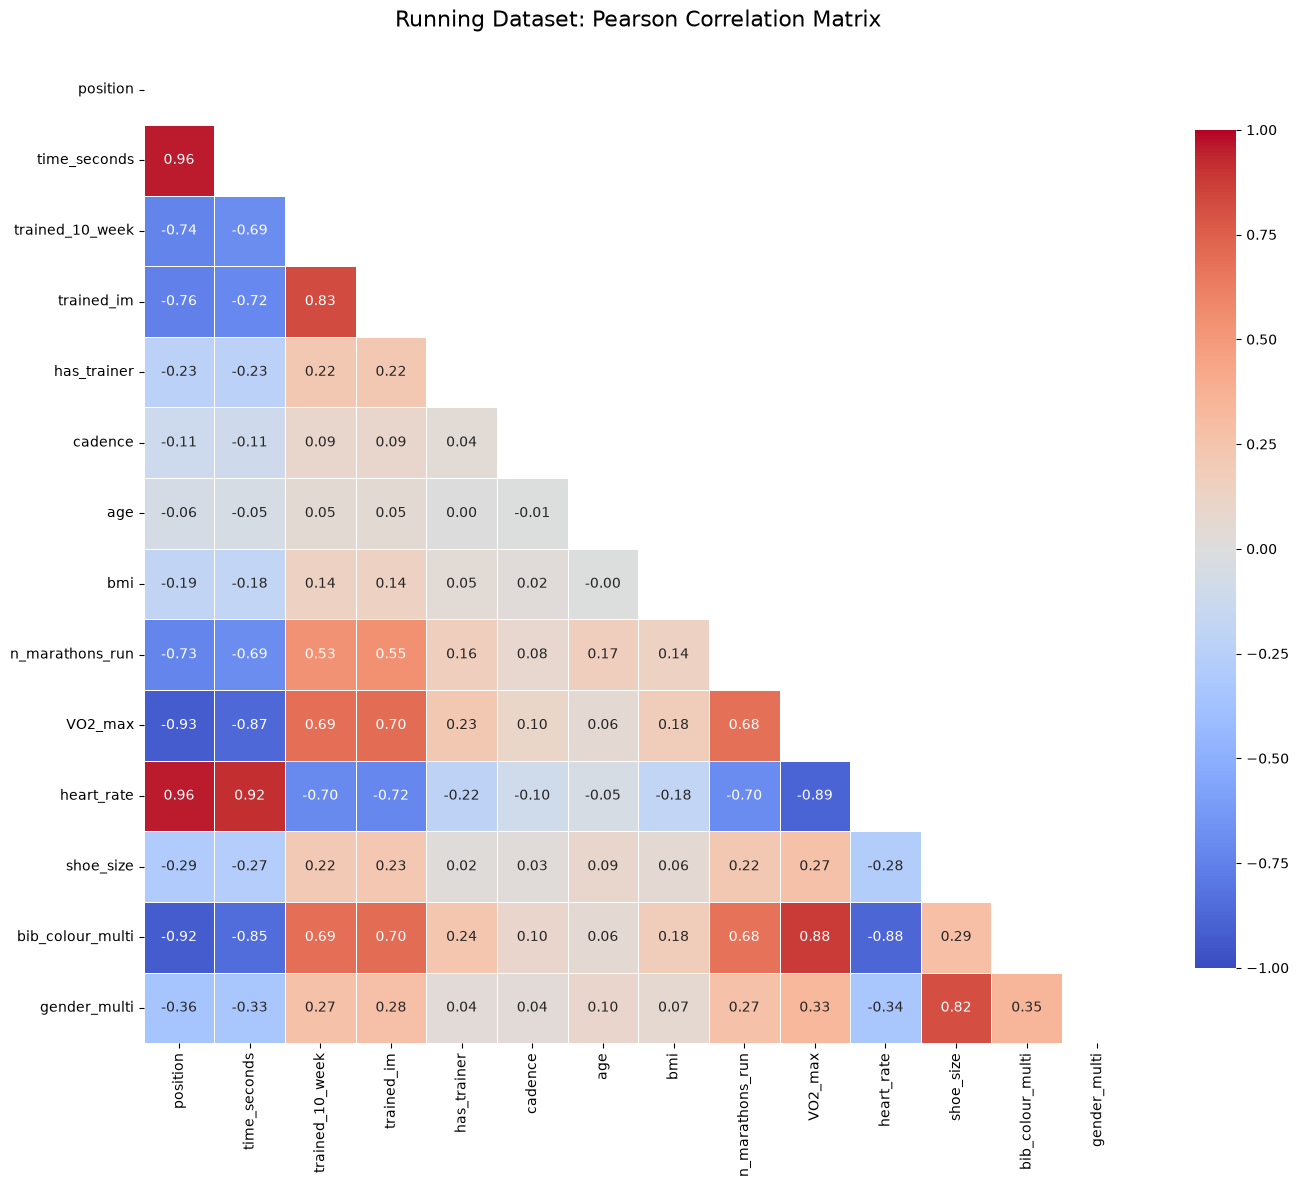

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Define your exact list of columns
columns = [
    "position",
    "time_seconds",
    "trained_10_week",
    "trained_im",
    "has_trainer",
    "cadence",
    "age",
    "bmi",
    "n_marathons_run",
    "VO2_max",
    "heart_rate",
    "shoe_size",
    "bib_colour_multi",
    "gender_multi",
]

# 2. Compute the Pearson correlation matrix on your DataFrame
corr = df[columns].corr(method="pearson")

# 3. Generate a boolean mask for the upper triangle
# This hides the redundant mirror reflection and keeps the plot clean
mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Set up the matplotlib figure size (larger to fit all 14 variables)
plt.figure(figsize=(14, 12))

# 5. Plot the triangular heatmap
sns.heatmap(
    corr,
    mask=mask,
    annot=True,  # Displays numbers inside the squares
    fmt=".2f",  # Rounds visual annotations to 2 decimal places
    cmap="coolwarm",  # Red for positive correlation, blue for negative
    vmin=-1,
    vmax=1,  # Standardizes the color scale limits
    square=True,  # Forces cells to be perfect squares
    linewidths=0.5,  # Adds clean white borders between cells
    cbar_kws={"shrink": 0.8},  # Shrinks colorbar slightly for visual balance
)

# 6. Add a title and tweak layout so labels don't get cut off
plt.title("Running Dataset: Pearson Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


#Since there is a very strong correlation between the VO2_max and heart_rate, populating it with an average will affect the reliabilioty of the model to accurately predict the performance of a runner, and since the unique number of rows with the intersection of both these values is less than 10% of the data, we have chosen to eliminate it


In [15]:
(df["bib_colour"][df["cadence"] == 1.00000]).value_counts()

bib_colour
green     236
blue      155
yellow     98
red        55
Name: count, dtype: int64

In [16]:

average_timings = df.groupby(['bib_colour', 'gender'])['time_seconds'].mean().reset_index()
average_timings.columns = ['Bib Color', 'Gender', 'Average Seconds']

# 2. Convert the average seconds into HH:MM:SS format
average_timings['Average HH:MM:SS'] = pd.to_timedelta(average_timings['Average Seconds'].round(), unit='s')
average_timings['Average HH:MM:SS'] = average_timings['Average HH:MM:SS'].apply(lambda x: str(x).split()[-1])

print(average_timings)

  Bib Color  Gender  Average Seconds Average HH:MM:SS
0      blue  female      5677.653367         01:34:38
1      blue    male      5596.512185         01:33:17
2     green  female      7109.111261         01:58:29
3     green    male      6986.444109         01:56:26
4       red  female      4122.849206         01:08:43
5       red    male      4093.336297         01:08:13
6    yellow  female      4902.482051         01:21:42
7    yellow    male      4823.593277         01:20:24


In [17]:
# a.
# - clean and why you clean what you clean
# - mean, std, min, max, basically .describe()
# - yap about distribution (maybe pair plot)

# b.
# - pearson correlation matrix

# c.
# get rid of position
# inc VO2_max, heart rate, times trained both variables, bib colour, n_marathons_run (mandatory)
# gender

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

In [38]:
# Target variable
y = df["time_seconds"]

# Features
X = df.drop(columns=[
    "time",             # string time
    "position",         # proxy for time
    "time_seconds",
    "time_hours",       # remove this if you created it earlier
    "Unnamed: 0",       # index column
    "id"                # ID shouldn't be predictive
], errors="ignore")

print(X.columns)
print(X.dtypes)

numeric_features = [
    "age",
    "bmi",
    "n_marathons_run",
    "VO2_max",
    "heart_rate",
    "shoe_size",
    "cadence"
]

categorical_features = [
    "club",
    "gender",
    "trained_10_week",
    "trained_im",
    "has_trainer",
    "bib_colour"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

decision_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor())
])

Index(['club', 'gender', 'trained_10_week', 'trained_im', 'has_trainer',
       'cadence', 'age', 'bmi', 'n_marathons_run', 'bib_colour', 'VO2_max',
       'heart_rate', 'shoe_size', 'bib_colour_multi', 'gender_multi'],
      dtype='str')
club                    str
gender                  str
trained_10_week     float64
trained_im          float64
has_trainer           int64
cadence               int64
age                 float64
bmi                 float64
n_marathons_run     float64
bib_colour              str
VO2_max             float64
heart_rate          float64
shoe_size             int64
bib_colour_multi      int64
gender_multi          int64
dtype: object
Training observations: 11538
Testing observations: 2885


In [ ]:
# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),

    # Create x² terms and interactions
    ("poly", PolynomialFeatures(
        degree=2,
        include_bias=False
    ))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Quadratic regression model
quadratic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [ ]:
# ---------------------------------------------------------
# FIT BOTH MODELS
# ---------------------------------------------------------

linear_model.fit(X_train, y_train)
y_train_pred_linear = linear_model.predict(X_train)
y_test_pred_linear = linear_model.predict(X_test)

In [ ]:
quadratic_model.fit(X_train, y_train)
y_train_pred_quad = quadratic_model.predict(X_train)
y_test_pred_quad = quadratic_model.predict(X_test)

In [30]:
forest_model.fit(X_train, y_train)
y_train_pred_forest = forest_model.predict(X_train)
y_test_pred_forest = forest_model.predict(X_test)

In [40]:
decision_model.fit(X_train, y_train)
y_train_pred_decision = decision_model.predict(X_train)
y_test_pred_decision = decision_model.predict(X_test)

            Model  Train R²  Test R²  Train RMSE (seconds)  \
0          Linear     0.989   -0.289               127.702   
1       Quadratic     0.993   -7.799               105.061   
2   Random Forest     1.000    0.879                 0.000   
3  Decision Trees     1.000    0.876                 0.000   

   Test RMSE (seconds)  
0             1401.032  
1             3660.478  
2              430.067  
3              435.346  


/tmp/ipykernel_5610/3736475800.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


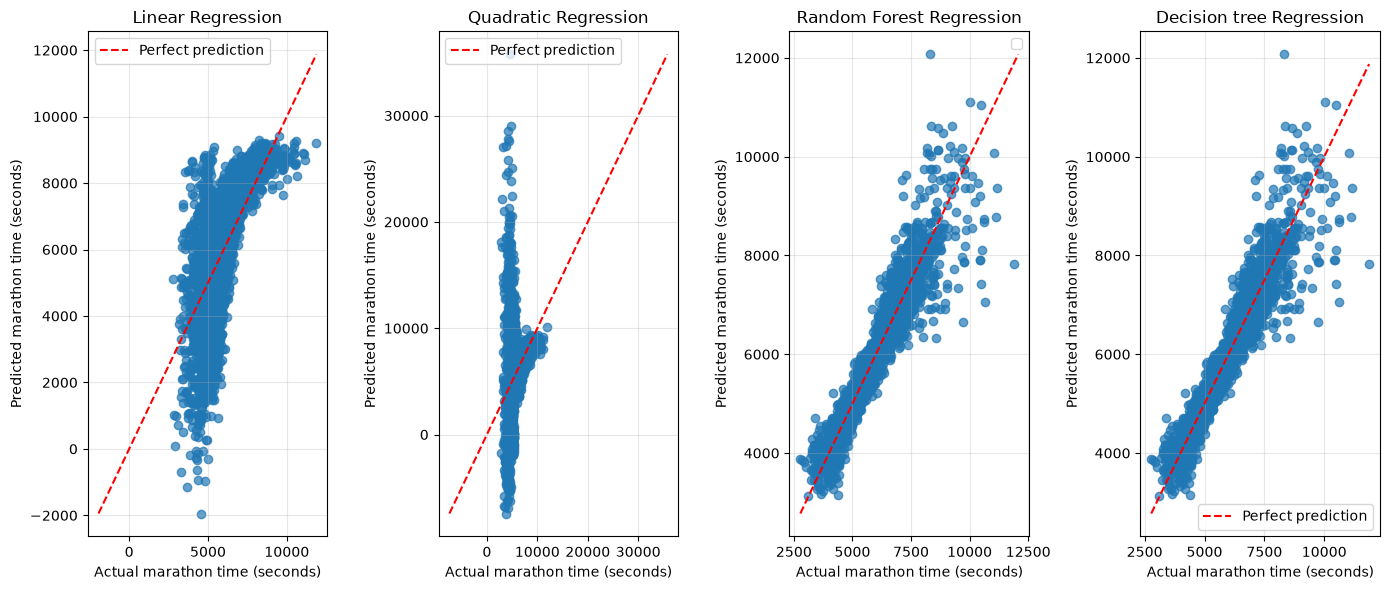

In [42]:

# ---------------------------------------------------------
# CALCULATE METRICS
# ---------------------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Linear",
        "Quadratic",
        "Random Forest",
        "Decision Trees"
    ],

    "Train R²": [
        r2_score(y_train, y_train_pred_linear),
        r2_score(y_train, y_train_pred_quad),
        r2_score(y_train, y_train_pred_forest),
        r2_score(y_train, y_train_pred_decision)
    ],

    "Test R²": [
        r2_score(y_test, y_test_pred_linear),
        r2_score(y_test, y_test_pred_quad),
        r2_score(y_test, y_test_pred_forest),
        r2_score(y_test, y_test_pred_decision)
    ],

    "Train RMSE (seconds)": [
        np.sqrt(mean_squared_error(y_train, y_train_pred_linear)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_quad)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_forest)),
        np.sqrt(mean_squared_error(y_train, y_train_pred_decision))
    ],

    "Test RMSE (seconds)": [
        np.sqrt(mean_squared_error(y_test, y_test_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_quad)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_forest)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_decision))
    ]
})

print(results.round(3))

# ---------------------------------------------------------
# ACTUAL VS PREDICTED PLOT
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(14, 6))

# ---- Linear model ----

axes[0].scatter(
    y_test,
    y_test_pred_linear,
    alpha=0.7
)

# Perfect prediction line
min_val = min(y_test.min(), y_test_pred_linear.min())
max_val = max(y_test.max(), y_test_pred_linear.max())

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Perfect prediction"
)

axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Actual marathon time (seconds)")
axes[0].set_ylabel("Predicted marathon time (seconds)")
axes[0].legend()
axes[0].grid(alpha=0.3)


# ---- Quadratic model ----

axes[1].scatter(
    y_test,
    y_test_pred_quad,
    alpha=0.7
)

min_val = min(y_test.min(), y_test_pred_quad.min())
max_val = max(y_test.max(), y_test_pred_quad.max())

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Perfect prediction"
)

axes[1].set_title("Quadratic Regression")
axes[1].set_xlabel("Actual marathon time (seconds)")
axes[1].set_ylabel("Predicted marathon time (seconds)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ---- Decision Tree model ----

axes[3].scatter(
    y_test,
    y_test_pred_forest,
    alpha=0.7
)

min_val = min(y_test.min(), y_test_pred_decision.min())
max_val = max(y_test.max(), y_test_pred_decision.max())

axes[3].plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Perfect prediction"
)
axes[2].set_title("Random Forest Regression")
axes[2].set_xlabel("Actual marathon time (seconds)")
axes[2].set_ylabel("Predicted marathon time (seconds)")
axes[2].legend()
axes[2].grid(alpha=0.3)

# ---- Random Forest model ----

axes[2].scatter(
    y_test,
    y_test_pred_forest,
    alpha=0.7
)

min_val = min(y_test.min(), y_test_pred_forest.min())
max_val = max(y_test.max(), y_test_pred_forest.max())

axes[2].plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Perfect prediction"
)
axes[3].set_title("Decision tree Regression")
axes[3].set_xlabel("Actual marathon time (seconds)")
axes[3].set_ylabel("Predicted marathon time (seconds)")
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Number of trees: 100
Feature importances: [0.00617722 0.01008148 0.11398175 ... 0.60701578 0.01255898 0.01255648]
Sum: 1.0
Number of nodes: 14469
Number of leaves: 7235
Max depth: 45

Top 10 features:
                 feature  importance
6                cadence    0.005781
0                    age    0.006177
1                    bmi    0.010081
21013  bib_colour_yellow    0.012556
21012     bib_colour_red    0.012559
3                VO2_max    0.024408
4             heart_rate    0.063235
21010    bib_colour_blue    0.110321
2        n_marathons_run    0.113982
21011   bib_colour_green    0.607016


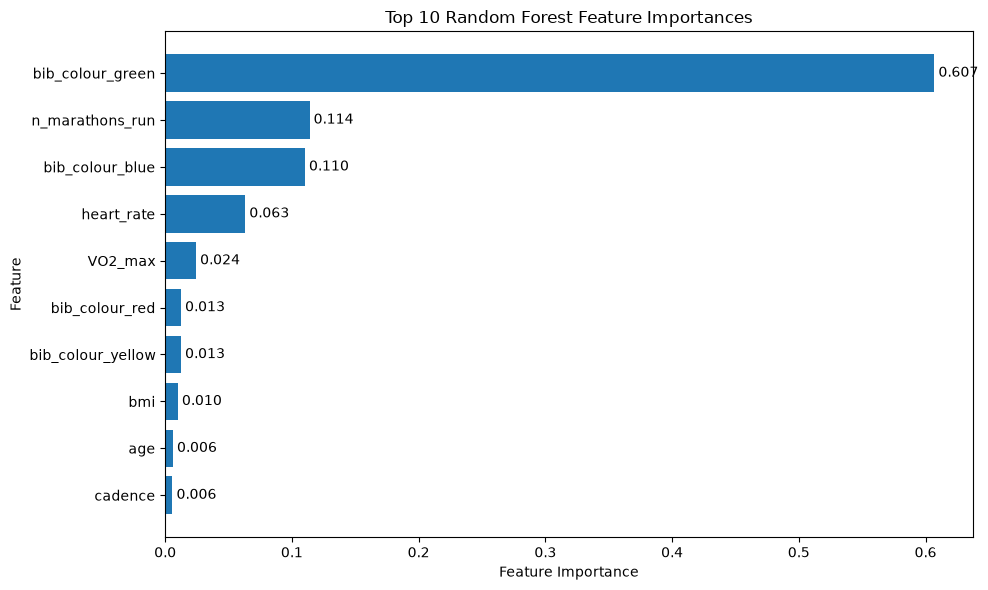

In [36]:
forest = forest_model.named_steps["model"]

print("Number of trees:", len(forest.estimators_))
print("Feature importances:", forest.feature_importances_)
print("Sum:", forest.feature_importances_.sum())

# Inspect the first tree
tree = forest.estimators_[0].tree_

print("Number of nodes:", tree.node_count)
print("Number of leaves:", tree.n_leaves)
print("Max depth:", tree.max_depth)

# -----------------------------------
# Feature importance
# -----------------------------------

# Get feature names after preprocessing
feature_names = (
    forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Create dataframe
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": forest.feature_importances_
})

# Remove preprocessing prefixes
feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Get top 10
top_10 = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance", ascending=True)
)

print("\nTop 10 features:")
print(top_10)


# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10["feature"],
    top_10["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

# Add values to the bars
for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()